## MP in the water column + sea water parameters

This notebook treats the output dataset provided by Camille Richon used in Zooplankton exposure to microplastics at global scale: Influence of vertical distribution and seasonality (https://doi.org/10.3389/fmars.2022.947309). \
Expoited sea water parameters are:\
POC:
  long_name: Small organic carbon Concentration
  units: mmol/m3
  
PHY:
  long_name: (Nano)Phytoplankton Concentration
  units: mmol/m3

ZOO:
  long_name: (Micro)Zooplankton Concentration
  units: mmol/m3

PHY2:
  long_name: Diatoms Concentration
  units: mmol/m3

ZOO2:
  long_name: Mesozooplankton Concentration
  units: mmol/m3

GOC:
  long_name: Big organic carbon Concentration
  units: mmol/m3

NO3:
  long_name: Nitrate Concentration
  units: mmol/m3

PLAS_F:
  long_name: Bouyant Plastic particles concentrations
  units: mgPlastic/m3

PLAS_C:
  long_name: Sinking Plastic particles concentrations
  units: mgPlastic/m3

PLAS_N:
  long_name: Neutral Plastic particles concentrations
  units: mgPlastic/m3

O2:
  long_name: Oxygen Concentration
  units: mmol/m3

PO4:
  long_name: Phosphate Concentration
  units: mmol/m3

Mean values over time (since 1900) and over all depths are used.

In [1]:
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  
import cartopy.feature as cfeature
import numpy as np
from shapely import area
from geopy.distance import geodesic
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

In [2]:
ds = nc.Dataset('inputs\ETOPO_PLASTIC_05_1m_ptrc_25.nc')

In [3]:
ds.variables.keys()

dict_keys(['time_counter', 'time_counter_bnds', 'ETOPO60X', 'ETOPO60Y', 'deptht', 'deptht_bnds', 'POC', 'PHY', 'ZOO', 'PHY2', 'ZOO2', 'GOC', 'NO3', 'PLAS_F', 'PLAS_C', 'PLAS_N', 'O2', 'PO4'])

In [4]:
parameters = ['POC', 'PHY', 'ZOO', 'PHY2', 'ZOO2', 'GOC', 'NO3', 'PLAS_F', 'PLAS_C', 'PLAS_N', 'O2', 'PO4']

In [5]:
# Description of each variable
for param in ds.variables.keys():
    var = ds.variables[param]
    print(f"\n{param}:")
    print(f"  long_name: {getattr(var, 'long_name', 'N/A')}")
    print(f"  units: {getattr(var, 'units', 'N/A')}")
    print(f"  standard_name: {getattr(var, 'standard_name', 'N/A')}")


time_counter:
  long_name: Time axis
  units: seconds since 1900-01-01 00:00:00
  standard_name: time

time_counter_bnds:
  long_name: N/A
  units: N/A
  standard_name: N/A

ETOPO60X:
  long_name: longitude
  units: degrees_east
  standard_name: longitude

ETOPO60Y:
  long_name: latitude
  units: degrees_north
  standard_name: latitude

deptht:
  long_name: Vertical T levels
  units: m
  standard_name: N/A

deptht_bnds:
  long_name: N/A
  units: N/A
  standard_name: N/A

POC:
  long_name: Small organic carbon Concentration
  units: mmol/m3
  standard_name: N/A

PHY:
  long_name: (Nano)Phytoplankton Concentration
  units: mmol/m3
  standard_name: N/A

ZOO:
  long_name: (Micro)Zooplankton Concentration
  units: mmol/m3
  standard_name: N/A

PHY2:
  long_name: Diatoms Concentration
  units: mmol/m3
  standard_name: N/A

ZOO2:
  long_name: Mesozooplankton Concentration
  units: mmol/m3
  standard_name: N/A

GOC:
  long_name: Big organic carbon Concentration
  units: mmol/m3
  standard_nam

In [6]:
lats = ds.variables["ETOPO60Y"][:].data
lons = ds.variables["ETOPO60X"][:].data

In [8]:
# Sample points dataset
data_points = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [9]:
latitudes_data  = np.array(data_points["Lat_center"], dtype=float)
longitudes_data = np.array(data_points["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]

lats_data = np.array(lats_data)
lons_data = np.array(lons_data)

In [10]:
print('lons',lons.min(), lons.max())
print('lats',lats.min(), lats.max())

lons 20.5 379.5
lats -89.5 89.5


In [11]:
# Compute param mean values
param_means = {}
for param in parameters:
    data = ds.variables[param][:]
    data_filled = np.where(data.mask, np.nan, data.data)
    
    param_means[param] = np.nanmean(data_filled, axis=(0, 1))

# Ocean mask 
ocean_mask = ~np.isnan(param_means["POC"])
ocean_lats, ocean_lons = np.where(ocean_mask)

# 3. Loop over coordinates
results = []
for lat, lon in zip(lats_data, lons_data):
    i_lat = np.argmin(np.abs(lats - lat))
    i_lon = np.argmin(np.abs(lons - lon))
    
    if not ocean_mask[i_lat, i_lon]:  # land point -> find nearest ocean
        distances = (ocean_lats - i_lat)**2 + (ocean_lons - i_lon)**2
        nearest = np.argmin(distances)
        i_lat, i_lon = ocean_lats[nearest], ocean_lons[nearest]
    
    row = {"latitude": lat, "longitude": lon}
    for param in parameters:
        row[param] = float(param_means[param][i_lat, i_lon])
    results.append(row)

df_params = pd.DataFrame(results)

C:\Users\nelad\AppData\Local\Temp\ipykernel_42512\1284463683.py:7: RuntimeWarning: Mean of empty slice
  param_means[param] = np.nanmean(data_filled, axis=(0, 1))


In [12]:
df_params

,latitude,longitude,POC,PHY,ZOO,PHY2,ZOO2,GOC,NO3,PLAS_F,PLAS_C,PLAS_N,O2,PO4
0,-74.5,163.5,0.284892,0.075945,0.052890,0.267331,0.177884,0.051679,30.147657,2.422132e-11,3.224271e-30,5.880389e-07,313.035645,2.156806
1,-74.5,164.5,0.284892,0.075945,0.052890,0.267331,0.177884,0.051679,30.147657,2.422132e-11,3.224271e-30,5.880389e-07,313.035645,2.156806
2,-42.5,147.5,1.009483,0.456341,0.374088,0.192877,0.368656,0.101018,12.592777,3.014510e-02,8.094767e-09,1.335144e-02,269.361511,0.923474
3,-38.5,144.5,2.383982,1.225903,1.301315,0.098275,0.781674,0.095268,3.380618,3.613249e+00,2.678285e-06,2.246786e-02,256.604553,0.397015
4,-35.5,138.5,0.980996,0.491285,0.350422,0.035352,0.277538,0.069492,8.158886,4.466439e+00,1.149244e-09,2.678790e-02,249.617126,0.613222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,73.5,-169.5,0.589907,0.306675,0.200788,0.301510,0.253358,0.075495,9.225160,7.694486e-03,2.992519e-19,1.240624e-02,312.317719,0.684199
100,73.5,-168.5,0.589907,0.306675,0.200788,0.301510,0.253358,0.075495,9.225160,7.694486e-03,2.992519e-19,1.240624e-02,312.317719,0.684199
101,74.5,-173.5,0.842469,0.548226,0.381605,0.638042,0.377822,0.077059,8.507728,7.256080e-03,1.285050e-20,1.102715e-02,330.371613,0.662826
102,75.5,-179.5,0.531767,0.278140,0.198728,0.355271,0.247332,0.056304,9.761839,4.217860e-03,3.937658e-21,9.731285e-03,331.915558,0.739494


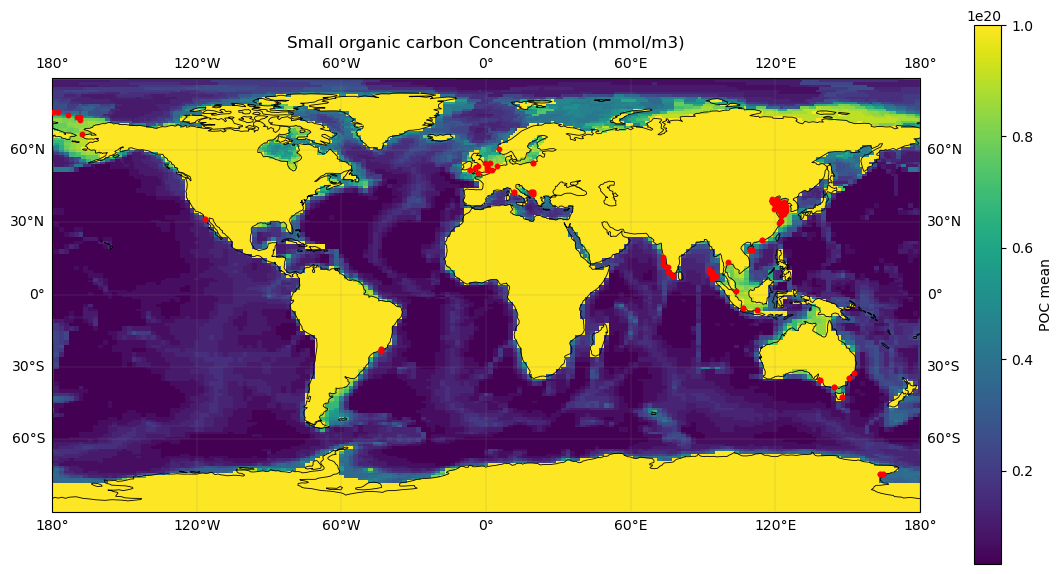

In [21]:
# Visual represetntation

lon_grid, lat_grid = np.meshgrid(lons, lats)

fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0")
ax.add_feature(cfeature.OCEAN, facecolor="#a8c8e8")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
#ax.set_extent([58, 90, 0, 24], crs=ccrs.PlateCarree())

# Plot a parameter as a heatmap instead of scatter
poc_mean = np.mean(ds.variables["POC"][:].data, axis=(0, 1))  # shape (180, 360)
im = ax.pcolormesh(lon_grid, lat_grid, poc_mean, cmap="viridis", transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label="POC mean")
plt.title('Small organic carbon Concentration (mmol/m3)')

ax.scatter(lons_data, lats_data, s=10, color="red", zorder=3, transform=ccrs.PlateCarree())
plt.show()

In [126]:
data_points

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
100,Fragments,73.5,-169.5,2.962179e-01,NaN,1
101,Fragments,73.5,-168.5,3.155131e-01,NaN,1
102,Fragments,74.5,-173.5,1.647974e-01,NaN,1
103,Fragments,75.5,-179.5,8.402756e-01,NaN,1


In [127]:
data_points_expended = pd.concat([data_points, df_params[parameters]], axis = 1)
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,POC,PHY,ZOO,PHY2,ZOO2,GOC,NO3,PLAS_F,PLAS_C,PLAS_N,O2,PO4
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,0.284892,0.075945,0.052890,0.267331,0.177884,0.051679,30.147657,2.422132e-11,3.224271e-30,5.880389e-07,313.035645,2.156806
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,0.284892,0.075945,0.052890,0.267331,0.177884,0.051679,30.147657,2.422132e-11,3.224271e-30,5.880389e-07,313.035645,2.156806
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,1.009483,0.456341,0.374088,0.192877,0.368656,0.101018,12.592777,3.014510e-02,8.094767e-09,1.335144e-02,269.361511,0.923474
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,2.383982,1.225903,1.301315,0.098275,0.781674,0.095268,3.380618,3.613249e+00,2.678285e-06,2.246786e-02,256.604553,0.397015
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,0.980996,0.491285,0.350422,0.035352,0.277538,0.069492,8.158886,4.466439e+00,1.149244e-09,2.678790e-02,249.617126,0.613222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Fragments,73.5,-169.5,2.962179e-01,NaN,1,0.589907,0.306675,0.200788,0.301510,0.253358,0.075495,9.225160,7.694486e-03,2.992519e-19,1.240624e-02,312.317719,0.684199
101,Fragments,73.5,-168.5,3.155131e-01,NaN,1,0.589907,0.306675,0.200788,0.301510,0.253358,0.075495,9.225160,7.694486e-03,2.992519e-19,1.240624e-02,312.317719,0.684199
102,Fragments,74.5,-173.5,1.647974e-01,NaN,1,0.842469,0.548226,0.381605,0.638042,0.377822,0.077059,8.507728,7.256080e-03,1.285050e-20,1.102715e-02,330.371613,0.662826
103,Fragments,75.5,-179.5,8.402756e-01,NaN,1,0.531767,0.278140,0.198728,0.355271,0.247332,0.056304,9.761839,4.217860e-03,3.937658e-21,9.731285e-03,331.915558,0.739494


In [128]:
data_points_expended.to_csv('outputs\Sea water concentrations dataset.csv', index=False)

## Statistics

In [129]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [130]:
spearman_results = []

# Fibers

for key in parameters:
    x = data_points_fib[key]
    y = data_points_fib['MEAN MP stock (g/m2) in 2021']

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))
    

# Fragmanrts
for key in parameters:
    x = data_points_frg[key]
    y = data_points_frg['MEAN MP stock (g/m2) in 2021']


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fragments stock', spearman_stock[0], spearman_stock[1]))
    
# Both
for key in parameters:
    x = data_points_copy[key]
    y = data_points_copy['MEAN MP stock (g/m2) in 2021']


    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} both stock', spearman_stock[0], spearman_stock[1]))
    


In [131]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
11,PO4 fibers stock,-0.512420,1.279154e-05
6,NO3 fibers stock,-0.465232,9.431248e-05
23,PO4 fragments stock,-0.438001,4.703266e-03
18,NO3 fragments stock,-0.310966,5.080949e-02
30,NO3 both stock,-0.300689,1.828722e-03
35,PO4 both stock,-0.283551,3.376908e-03
33,PLAS_N both stock,-0.130454,1.846958e-01
32,PLAS_C both stock,-0.014905,8.800490e-01
31,PLAS_F both stock,0.048287,6.247317e-01
17,GOC fragments stock,0.087792,5.901069e-01


## Visualise

In [132]:
n = len(parameters)
if n % 2 == 0: n = n//2
else: n = n//2 + 1

In [133]:
cmap = plt.colormaps['plasma']
data_points_copy["Author"] = data_points_copy.index
colors = cmap(np.linspace(0, 1, len(data_points_copy["Author"].unique())))

C:\Users\nelad\AppData\Local\Temp\ipykernel_7328\1087042632.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[parameters.index(key) // 2, parameters.index(key) % 2].scatter(subset[key], subset[concentration_type], c=colors[i])


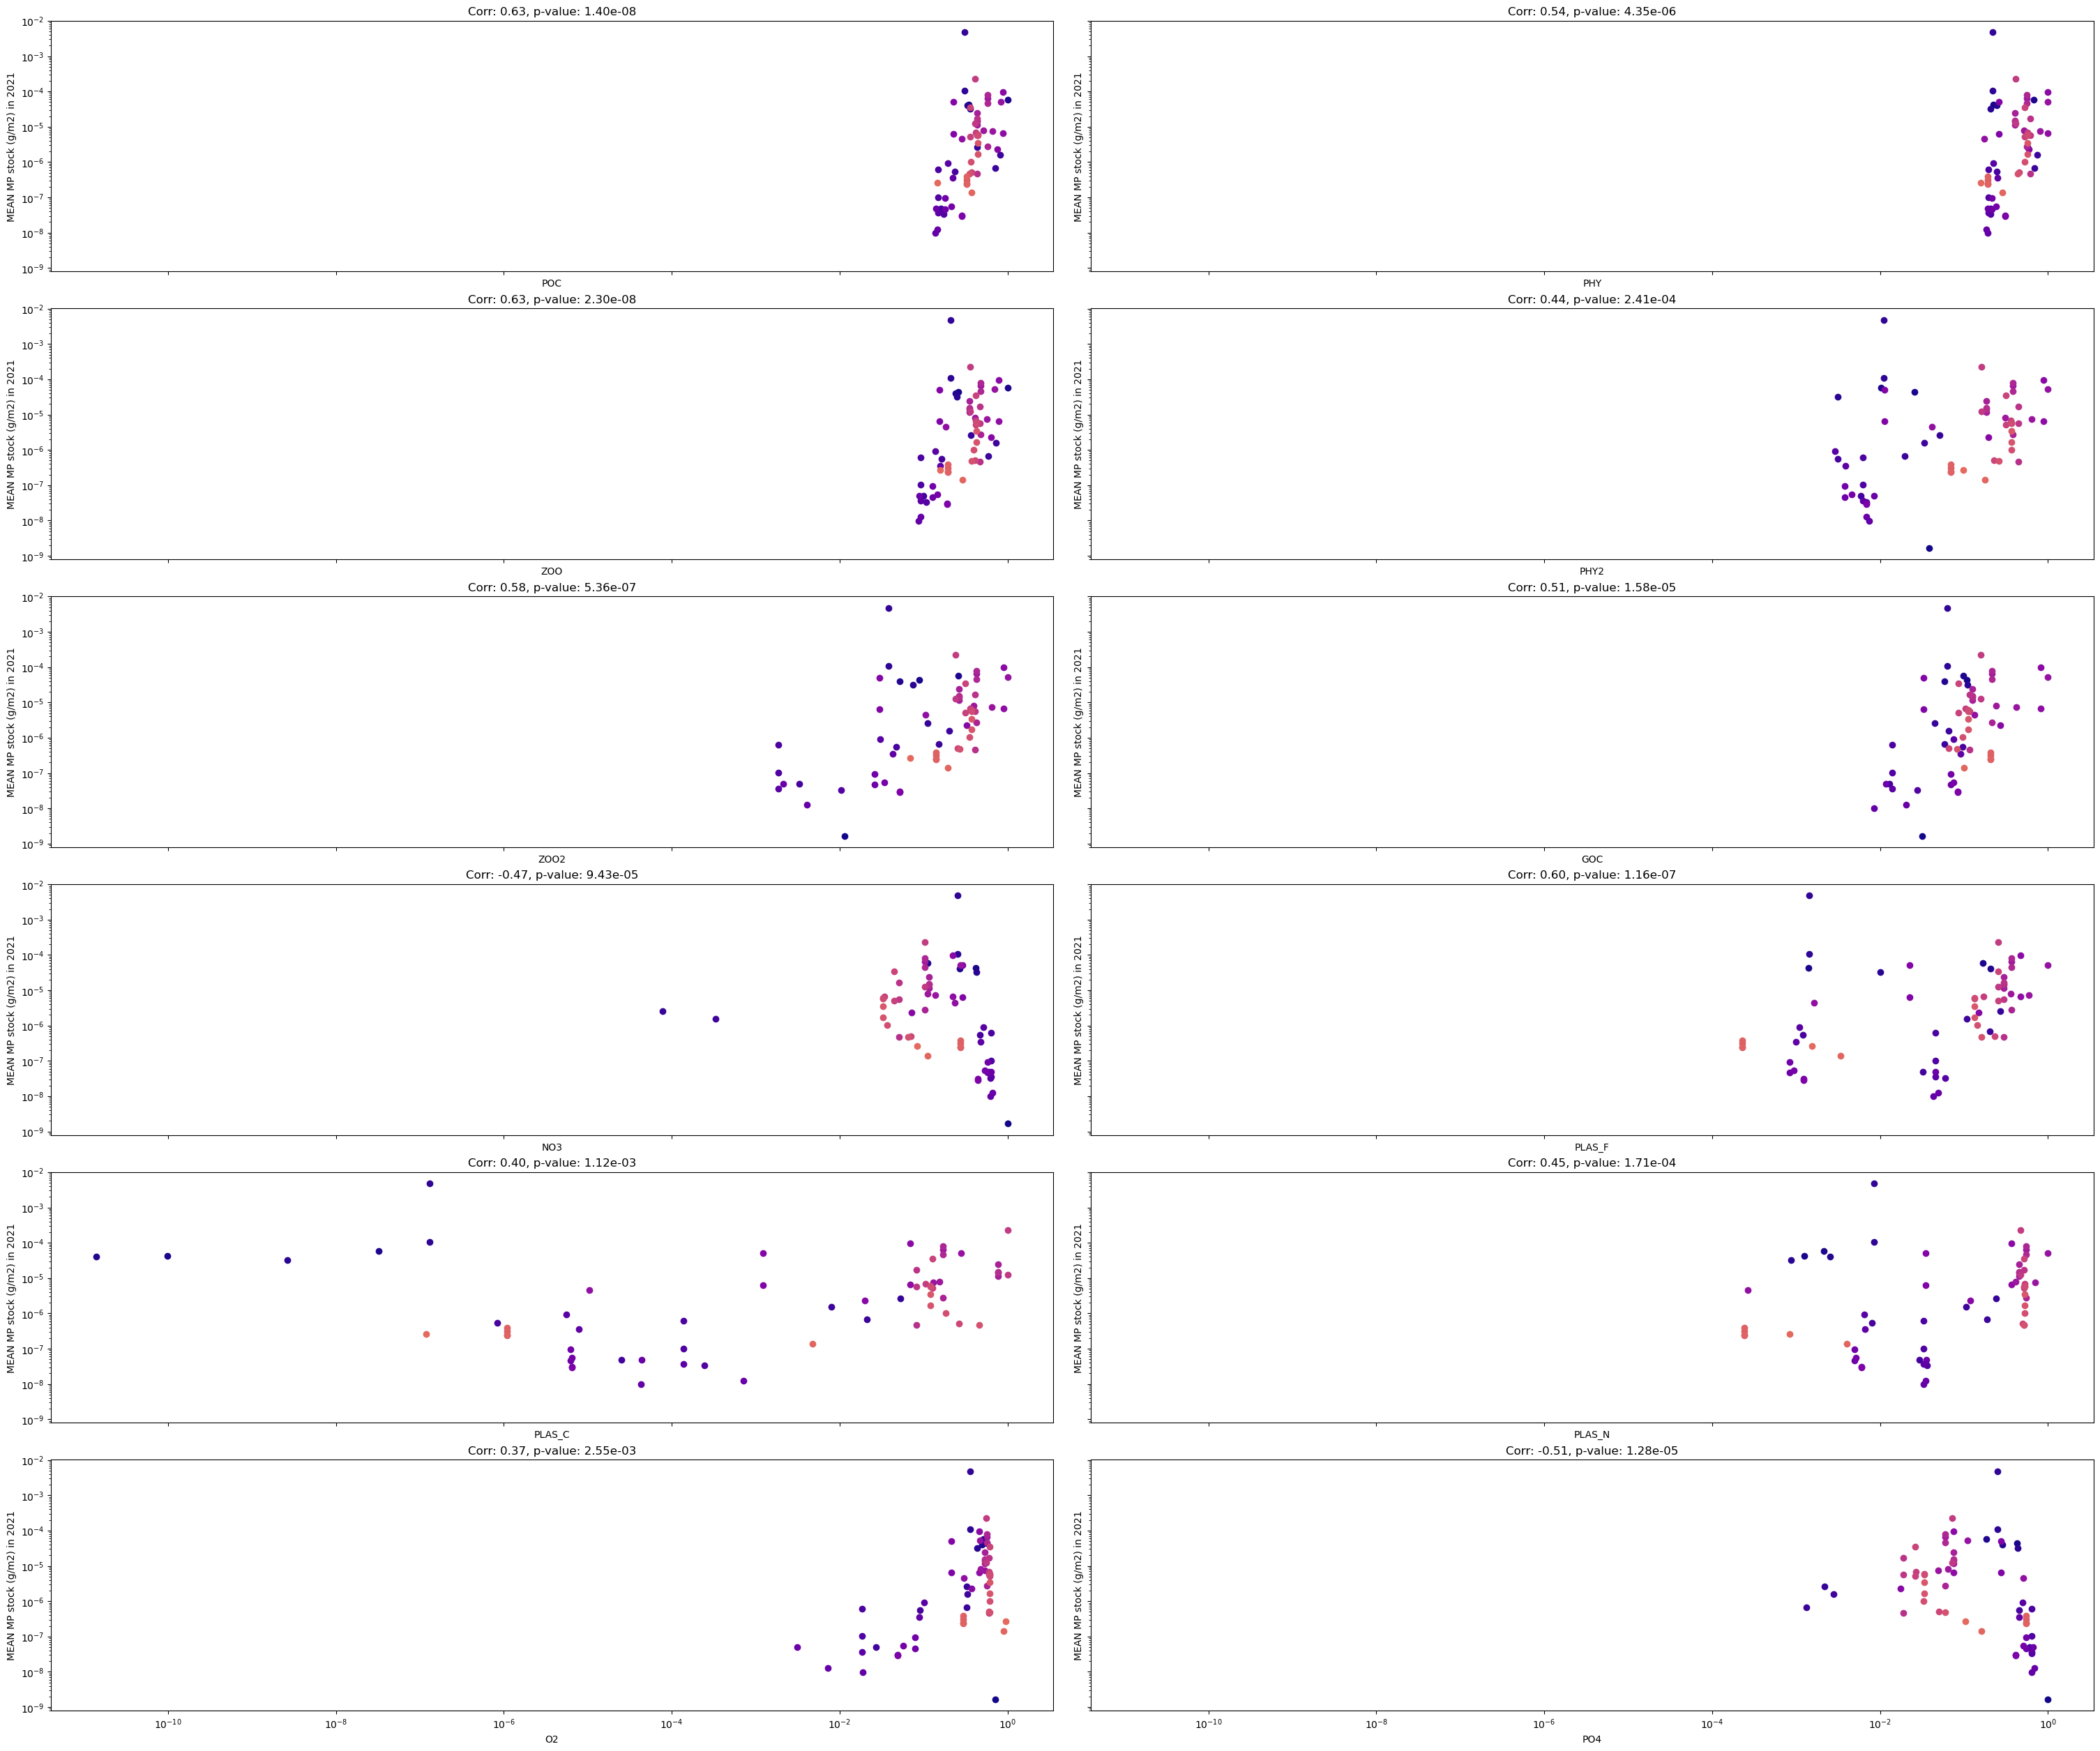

In [134]:
fig, axs = plt.subplots(n, 2, sharex=True, sharey=True, layout="constrained",figsize=(30, 25))
spearman_results = []


dataset_shape = data_points_fib # data_points_frg # data_points_copy
dataset_shape["Author"] = dataset_shape.index
concentration_type = "MEAN MP stock (g/m2) in 2021" # "MP mass observation extrapolated to 1-5000 µm (µg/kg) from MPsizeBase"

for key in parameters:

    x = dataset_shape[key]
    y = dataset_shape[concentration_type]

    # Remove NaNs from both arrays
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]

    spearman = stats.spearmanr(x_clean, y_clean)
    spearman_results.append((key, spearman[0], spearman[1]))
    
    for i, author in enumerate(dataset_shape["Author"].unique()):
        
        subset = dataset_shape[dataset_shape["Author"] == author]
        
        axs[parameters.index(key) // 2, parameters.index(key) % 2].scatter(subset[key], subset[concentration_type], c=colors[i])
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_xlabel(key)
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_ylabel(concentration_type)
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_title(f"Corr: {spearman[0]:.2f}, p-value: {spearman[1]:.2e}")

plt.xscale("log")
plt.yscale("log")